In [1]:
####################################
#ENVIRONMENT SETUP

In [2]:
#Importing Libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr

import sys; import os; import time; from datetime import datetime, timedelta
import pickle
import h5py
from tqdm import tqdm

In [3]:
#MAIN DIRECTORIES
def GetDirectories():
    mainDirectory='/mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/'
    mainCodeDirectory=os.path.join(mainDirectory,"Code/CodeFiles/")
    scratchDirectory='/mnt/lustre/koa/scratch/air673/'
    codeDirectory=os.getcwd()
    return mainDirectory,mainCodeDirectory,scratchDirectory,codeDirectory

[mainDirectory,mainCodeDirectory,scratchDirectory,codeDirectory] = GetDirectories()

In [4]:
def GetPlottingDirectory(plotFileName, plotType):
    plottingDirectory = mainCodeDirectory=os.path.join(mainDirectory,"Code","PLOTTING")
    
    specificPlottingDirectory = os.path.join(plottingDirectory, plotType, 
                                             f"{ModelData.res}_{ModelData.t_res}_{ModelData.Nz_str}nz")
    os.makedirs(specificPlottingDirectory, exist_ok=True)

    plottingFileName=os.path.join(specificPlottingDirectory, plotFileName)

    return plottingFileName

In [5]:
#IMPORT CLASSES
sys.path.append(os.path.join(mainCodeDirectory,"2_Variable_Calculation"))
from CLASSES_Variable_Calculation import ModelData_Class, SlurmJobArray_Class, DataManager_Class

In [6]:
#IMPORT CLASSES
sys.path.append(os.path.join(mainCodeDirectory,"3_Project_Algorithms","2_Tracking_Algorithms"))
from CLASSES_TrackingAlgorithms import TrackingAlgorithms_DataLoading_Class

In [7]:
# IMPORT CLASSES
sys.path.append(os.path.join(mainCodeDirectory,"3_Project_Algorithms","3_Tracked_Profiles"))
from CLASSES_TrackedProfiles import TrackedProfiles_DataLoading_CLASS

In [8]:
#IMPORT FUNCTIONS
sys.path.append(os.path.join(mainCodeDirectory,"Variable_Calculation"))
import FUNCTIONS_Variable_Calculation
from FUNCTIONS_Variable_Calculation import * # import NumericalFunctions 

In [9]:
import sys
path=os.path.join(mainCodeDirectory,'Functions/')
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions

# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [10]:
####################################
#LOADING CLASSES

In [11]:
#data loading class
ModelData = ModelData_Class(mainDirectory, scratchDirectory, simulationNumber=1)
#data manager class
DataManager = DataManager_Class(mainDirectory, scratchDirectory, ModelData.res, ModelData.t_res, ModelData.Nz_str,
                                ModelData.Np_str, dataType="Tracking_Algorithms", dataName="Eulerian_CLTracking",
                                dtype='float32',codeSection = "Project_Algorithms")

=== CM1 Data Summary ===
 Simulation #:   1
 Resolution:     1km
 Time step:      5min
 Vertical levels:34
 Parcels:        1e6
 Data file:      /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Model/cm1r20.3/run/MODEL_OUTPUT/Test_Simulation/cm1out_1km_5min_34nz.nc
 Parcel file:    /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Model/cm1r20.3/run/MODEL_OUTPUT/Test_Simulation/cm1out_pdata_1km_5min_1e6np.nc
 Time steps:     133

=== DataManager Summary ===
 inputDirectory #:   /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Code/OUTPUT/Variable_Calculation/TimeSplitModelData
 outputDirectory #:   /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Code/OUTPUT/Project_Algorithms/Tracking_Algorithms
 inputDataDirectory #:   /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Code/OUTPUT/Variable_Calculation/TimeSplitModelData/1km_5min_34nz/ModelData
 inputParcelDirectory #:   /mn

In [12]:
####################################
#DATA LOADING FUNCTIONS

In [13]:
#TIME 00:00:00 Function
#Gets the realtime for the current timestep
def get_time(t):
    # init_day,init_hour,init_min=0,0,0
    init_day,init_hour,init_min=0,6,0
    times=ModelData.time/(1e9 * 60); time_inc=times.astype(int)[1]-times.astype(int)[0]
    current_min=init_hour*60+init_min+time_inc*t;
    
    days = init_day + (current_min // (24 * 60))
    
    remain_min = (init_min+time_inc*t) % (24 * 60); 
    hours = (init_hour + (remain_min // 60)) % 24
    mins = remain_min % 60

    ##############################################
    days=str(days);hours=str(hours);mins=str(mins)
    if len(days)==1:days='0'+days
    if len(hours)==1:hours='0'+hours
    if len(mins)==1:mins='0'+mins
    ##############################################

    combo=days+":"+hours+":"+mins
    return(days,hours,mins),(combo)

In [14]:
def get_theta_v(t): #*#*
    theta_v_data = CallVariable(ModelData, DataManager, ModelData.timeStrings[t], 'theta_v')
    theta_v_data_prime = theta_v_data - np.mean(theta_v_data, axis=(1,2), keepdims=True)
    return theta_v_data_prime

def LoadVars(t):
    theta_v_data=get_theta_v(t)[0]
    return theta_v_data

def MinMax_theta_v():
    # if len(array.shape) != 3:
        # raise ValueError("Data is not 2D + Time")
    print(f'working on theta_v\n')
    
    t=0
    array=get_theta_v(t)
    min_val=np.min(array[0])
    max_val=np.max(array[0])

    for t in tqdm(np.arange(1,len(ModelData.time))):
        # if np.mod(t,50)==0: print(f'current time {t}')
        
        array=get_theta_v(t)
        current_min=np.min(array[0])
        current_max=np.max(array[0])

        min_val=min(min_val,current_min)
        max_val=max(max_val,current_max)
    
    return (min_val,max_val)
def LoadorRun_MinMax_theta_v(recompute=False):

    filePath = DataManager.outputDataDirectory
    filePathName = os.path.join(filePath, "minmax_theta_v.npy")

    # ============================================================
    # LOAD
    # ============================================================
    if os.path.exists(filePathName) and not recompute:
        print(f"Load min/max theta_v from:\n {filePathName}")
        min_val, max_val = np.load(filePathName)
        return min_val, max_val

    # ============================================================
    # RUN
    # ============================================================
    print("Running MinMax_theta_v")
    min_val, max_val = MinMax_theta_v()

    # ============================================================
    # SAVE
    # ============================================================
    print(f"Saving min/max theta_v from {filePathName}")
    np.save(filePathName, np.array([min_val, max_val]))

    return min_val, max_val

In [15]:
def GetConvergence(t,z):
    timeString = ModelData.timeStrings[t]
    varName = 'convergence'
    convergence = CallVariable(ModelData, DataManager, timeString, varName)
    return convergence[z]
    
def LoadTrackedData(t,zIndex):
    timeString = ModelData.timeStrings[t]
    Dictionary = TrackingAlgorithms_DataLoading_Class.LoadData(ModelData,DataManager, timeString)
    # maxConvergence_X = Dictionary["maxConvergence_X"]
    maxConvergence_X_CL = Dictionary["maxConvergence_X_CL"]
    maxConvergence_X_turbulentCL = Dictionary["maxConvergence_X_turbulentCL"]
    CP_SBF_Mask=Dictionary["CP_SBF_Mask"]
    return maxConvergence_X_CL[zIndex],maxConvergence_X_turbulentCL[zIndex],CP_SBF_Mask

In [16]:
####################################
#DATA LOADING

In [17]:
#Getting Colorbar Levels 
theta_v_minmax = LoadorRun_MinMax_theta_v()

Load min/max theta_v from:
 /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Code/OUTPUT/Project_Algorithms/Tracking_Algorithms/1km_5min_34nz/Eulerian_CLTracking/minmax_theta_v.npy


In [18]:
####################################
#PLOTTING FUNCTIONS

In [19]:
def PlotThetaVContour(axis, variable, minmax_variable, levelsType="4",
                      cmap='RdBu_r', numlevels=9,
                      setXLabel=True,setYLabel=True,
                      ocean_fraction=2/8,
                      font_size=10):
    
    if levelsType=='1':
        levels = np.linspace(minmax_variable[0], minmax_variable[1], numlevels)
    elif levelsType=='2':
        max_abs = np.round(max(abs(minmax_variable[0]), abs(minmax_variable[1])),1)
        levels = np.linspace(-max_abs, max_abs, numlevels)
    elif levelsType=='3':
        max_abs = np.round(min(abs(minmax_variable[0]), abs(minmax_variable[1])),1)
        levels = np.linspace(-max_abs, max_abs, numlevels)
    elif levelsType=='4':
        levels = np.linspace(-5,5,numlevels)
        
    contour = axis.contourf(xh,yh,variable, levels=levels, cmap=cmap)
    cbar=plt.colorbar(contour, ax=axis, pad=0)
    cbar.set_label(r"$\theta_v'\ (K)$",rotation=90, fontsize=font_size)
    if setXLabel==True:
        axis.set_xlabel('x (km)', fontsize=font_size)
    if setYLabel==True:
        axis.set_ylabel('y (km)', fontsize=font_size)

    # Coastline
    axis.axvline(x=(ModelData.Nxf) * ocean_fraction, color='black', linewidth=1.5, label='Coastline')
xh=ModelData.xh-(ModelData.xh[0])
yh=ModelData.yh-(ModelData.yh[0])

In [20]:
def PlotConvergenceAndCL(axis, t, 
                         clim,numlevels=9,
                         font_size=10, index_adjust=0, ocean_fraction=2/8,
                         setXLabel=True,setYLabel=True,
                         cmap='RdBu_r'):

    #loading convergence data
    zlev = zlev = int(np.abs(ModelData.zh - 350/1e3).argmin())
    conv_z = GetConvergence(t, zlev)

    #plotting convergence
    if clim is not None:
        levels = np.linspace(clim[0] * 1000, clim[1] * 1000, numlevels)
    else:
        levels= numlevels
    
    contour = axis.contourf(xh, yh, conv_z * 1000, levels=levels, cmap=cmap)
    cbar = plt.colorbar(contour, ax=axis, pad=0)
    cbar.set_label(r'$-\nabla \cdot \vec{V}_H\ (10^-3\ s^{-1})$', fontsize=font_size)
    cbar.ax.tick_params(labelsize=font_size)
    cbar.ax.yaxis.label.set_size(font_size)

    if setXLabel==True:
        axis.set_xlabel('x (km)', fontsize=font_size)
    if setYLabel==True:
        axis.set_ylabel('y (km)', fontsize=font_size)
    
    axis.tick_params(axis='both', which='major', labelsize=font_size)

    #loading tracked CL data
    maxConvergence_X = LoadTrackedData(t)

    # Scatter max convergence points
    for yind in range(ModelData.Nyh):
        local_maxes = maxConvergence_X[zlev, yind]
        local_maxes = local_maxes[local_maxes != -1]
        local_maxes = local_maxes.astype(int)
        axis.scatter(xh[local_maxes], [yh[yind]] * len(local_maxes), color='k', s=0.1,alpha=0.5)
        
    # Coastline
    axis.axvline(x=(ModelData.Nxf) * ocean_fraction, color='black', linewidth=1.5, label='Coastline')

In [21]:
def GetTimesFromTimeIndiceRanges(timeIndiceRange):
    split=timeIndiceRange.split("-")
    [a,b] = int(split[0].split('_')[1]), int(split[1])
    return a,b

def ConvertTimeString(tString, initialTime=6):

    # parse string (HH-MM-SS)
    dt = datetime.strptime(tString, "%H-%M-%S")

    # add hours
    dt = dt + timedelta(hours=initialTime)

    # format output
    return dt.strftime("%H:%M")
    
def GetTimeInfo(timeIndiceRange):    
    [a,b] = GetTimesFromTimeIndiceRanges(timeIndiceRange)
    timeStrings_datetime = TrackedProfiles_DataLoading_CLASS.ConvertTimeStringsToDatetime(ModelData.timeStrings)
    tIndexes = TrackedProfiles_DataLoading_CLASS.FindTimeWindowIndices(timeStrings_datetime,a,b)
    tIndex = tIndexes[len(tIndexes)//2]
    tString = ConvertTimeString(ModelData.timeStrings[tIndex])
    return tIndex,tString 

In [22]:
#getting convergence xmax
def Get_AvgConvergence(t):

    timeString = ModelData.timeStrings[t]
    outputDataDirectory=os.path.normpath(os.path.join(DataManager.outputDataDirectory,"..","Eulerian_CLTracking"))
    Dictionary = TrackingAlgorithms_DataLoading_Class.LoadData(ModelData, DataManager, timeString,
                     dataName="Eulerian_CLTracking",outputDataDirectory=outputDataDirectory,printstatement=False)
    avgConvergence = Dictionary["avgConvergence"]
    return avgConvergence
    
def find_SBF_xmaxs():
    xmaxs=[]
    for t in tqdm(range(ModelData.Ntime)):
        if t == 0:
            xmaxs.append(np.nan)
        else:
            avgConvergence = Get_AvgConvergence(t)
            avgConvergence_max=np.nanmax(avgConvergence)
            xmax = np.where(avgConvergence==avgConvergence_max)[0][0]
            xmaxs.append(xmax)
    return xmaxs
xmaxs=find_SBF_xmaxs()

#get theta_v_prime
def GetTheta_v_prime(t):
    timeString=ModelData.timeStrings[t]
    varName = 'theta_v'
    theta_v = CallVariable(ModelData, DataManager, timeString, varName)[0]
    theta_v_prime = theta_v - np.mean(theta_v[:,xmaxs[t]+10:])
    return theta_v_prime

def GetConvergence_V2(t):
    timeString = ModelData.timeStrings[t]
    varName = 'convergence'
    convergence = CallVariable(ModelData, DataManager, timeString, varName)
    return convergence

#plotting CL points function
def PlotCLPoints(xh,yh,maxConvergence_X, axis=None,
                 color='black', size=0.2,
                 method='contour'):
    if axis is None:
        fig, axis = plt.subplots(figsize=(10, 4))

    if method=="point":
        for yind in range(len(yh)):
            localMaxes = maxConvergence_X[yind]
    
            # remove invalid points
            localMaxes = localMaxes[localMaxes != -1]
    
            if len(localMaxes) == 0:
                continue
    
            localMaxes = localMaxes.astype(int)
    
            axis.scatter(
                xh[localMaxes],
                # [yh[yind]] * len(local_maxes) #original
                np.full(len(localMaxes), yh[yind]),
                color=color,s=size,zorder=10,alpha=0.7)
    elif method=='contour':
        mask = maxConvergence_X != -1
        axis.contour(mask,colors='green',zorder=10,alpha=0.7)

    return axis

def MakePlot_combined(conv,maxConvergence_X,
                      theta_v_prime,CP_SBF_Mask,qr,
                      xh=ModelData.xh-(ModelData.xh[0]),
                      yh=ModelData.yh-(ModelData.yh[0]),
                      axis=None,
                      variableName='theta_v_prime'):
    if variableName=='conv':
        data=conv*1e3
        cbarLabel = r'$-\nabla \cdot \vec{V}_H\ (10^-3\ s^{-1})$'
        
        levels = np.arange(-3.5, 3.5+0.25, 0.25)
        cmap = plt.get_cmap('RdBu_r').copy()
        norm = mcolors.BoundaryNorm(levels, cmap.N)
        color='black'
    elif variableName=="theta_v_prime":
        data=theta_v_prime
        cbarLabel = r"$\theta_v'\ (K)$"
        levels = np.arange(-2, 2+0.25, 0.25)
        cmap = plt.get_cmap('RdBu_r').copy()
        norm = mcolors.BoundaryNorm(levels, cmap.N)
        color='green'
    
    if axis is None:
        plt.figure(figsize=(10, 4))
        plt.pcolormesh(xh,yh,data, cmap=cmap,norm=norm)
        cbar=plt.colorbar(extend='both',pad=0.01);cbar.set_label(cbarLabel)
        if qr is not None: plt.contour(qr,colors='red',zorder=20)
        plt.contour(CP_SBF_Mask,colors='cyan',zorder=5)
        plt.xlim(left=75)
    else:
        pcm=axis.pcolormesh(xh,yh,data, cmap=cmap,norm=norm)
        if qr is not None: axis.contour(qr,colors='red',zorder=20)
        axis.contour(CP_SBF_Mask,colors='cyan',zorder=5)
        PlotCLPoints(xh,yh,maxConvergence_X,axis=axis,color=color);
        axis.set_xlim(left=75)
        return pcm

def MakeAllPlots_combined(variableName='theta_v_prime',zHeight=350/1e3, CLType="CL"):

    zIndex=(np.abs(ModelData.zh - zHeight)).argmin()

    fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True, sharey=True)
    plt.subplots_adjust(hspace=0.2,wspace=0.02)
    axes = axes.flatten()
    
    pcm = None  # <-- added

    for i, timeIndiceRange in enumerate(timeIndiceRanges):
        axis = axes[i]
        tIndex, tString = GetTimeInfo(timeIndiceRange)
        [maxConvergence_X_CL,maxConvergence_X_turbulentCL,CP_SBF_Mask] = LoadTrackedData(t=tIndex,zIndex=zIndex)
        CP_SBF_Mask=CP_SBF_Mask[zIndex]
        theta_v_prime=GetTheta_v_prime(t=tIndex) if variableName == "theta_v_prime" else None
        conv=GetConvergence_V2(t=tIndex)[zIndex] if variableName == "conv" else None

        if variableName == "theta_v_prime":
            qr=CallVariable(ModelData, DataManager, 
                              timeString=ModelData.timeStrings[tIndex], variableName='qr')[0]
            qr[qr<=1e-6]=np.nan
        else:
            qr=None

        if CLType=="CL":
            maxConvergence_X_input = maxConvergence_X_CL
        elif CLType=="turbulentCL":
            maxConvergence_X_input = maxConvergence_X_turbulentCL
            
        result = MakePlot_combined(conv=conv,
                                  maxConvergence_X=maxConvergence_X_input,
                                  theta_v_prime=theta_v_prime,
                                  CP_SBF_Mask=CP_SBF_Mask,
                                  qr=qr,
                                  axis=axis,
                                  variableName=variableName)

        if pcm is None:
            pcm = result  # <-- added

        axis.set_title(f't = {tString}')

    # --- shared colorbar ---
    if variableName == 'conv':
        cbarLabel = r'$-\nabla \cdot \vec{V}_H\ (10^-3\ s^{-1})$'
    elif variableName == 'theta_v_prime':
        cbarLabel = r"$\theta_v'\ (K)$"

    # fig.colorbar(pcm, ax=axes, extend='both', pad=0.02).set_label(cbarLabel)
    fig.colorbar(pcm, ax=axes, extend='both', pad=0.02,
             fraction=0.03, aspect=30).set_label(cbarLabel)

    # formatting
    for ax in axes:
        ax.label_outer()
    for ax in axes[-2:]:
        ax.set_xlabel('x (km)')
    for ax in axes[::2]:
        ax.set_ylabel('y (km)')

    return fig

100%|██████████| 133/133 [00:02<00:00, 56.50it/s]


In [23]:
def SaveFigure(fig,plotType, fileName):
    plotFileName = f"{fileName}_{ModelData.res}_{ModelData.t_res}_{ModelData.Np_str}.jpg"
    plottingFileName = GetPlottingDirectory(plotFileName, plotType)
    print(f"Saving figure to {plottingFileName}")
    fig.savefig(plottingFileName, dpi=300, bbox_inches='tight')
    plt.close(fig)

In [24]:
####################################
#PLOTTING
timeIndiceRanges = ['_10-11', '_11-12', '_12-13', '_13-14','_14-15','_15-16']

In [ ]:
fig = MakeAllPlots_combined(variableName='conv',CLType="CL")
SaveFigure(fig,plotType=f"Project_Algorithms/Tracking_Algorithms/DiurnalCycleFigure",fileName=f"DiurnalCycleFigure_Convergence_CL")

In [30]:
fig = MakeAllPlots_combined(variableName='theta_v_prime',CLType="CL")
SaveFigure(fig,plotType=f"Project_Algorithms/Tracking_Algorithms/DiurnalCycleFigure",fileName=f"DiurnalCycleFigure_Theta_V_Prime_CL")

Loaded data from /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Code/OUTPUT/Project_Algorithms/Tracking_Algorithms/1km_5min_34nz/Eulerian_CLTracking/Eulerian_CLTracking_1km_5min_34nz_4-30-00.h5 (6 variables)

Loaded data from /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Code/OUTPUT/Project_Algorithms/Tracking_Algorithms/1km_5min_34nz/Eulerian_CLTracking/Eulerian_CLTracking_1km_5min_34nz_5-30-00.h5 (6 variables)

Loaded data from /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Code/OUTPUT/Project_Algorithms/Tracking_Algorithms/1km_5min_34nz/Eulerian_CLTracking/Eulerian_CLTracking_1km_5min_34nz_6-30-00.h5 (6 variables)

Loaded data from /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Code/OUTPUT/Project_Algorithms/Tracking_Algorithms/1km_5min_34nz/Eulerian_CLTracking/Eulerian_CLTracking_1km_5min_34nz_7-30-00.h5 (6 variables)

Loaded data from /mnt/lustre/koa/koastore/torri_group/air_direct

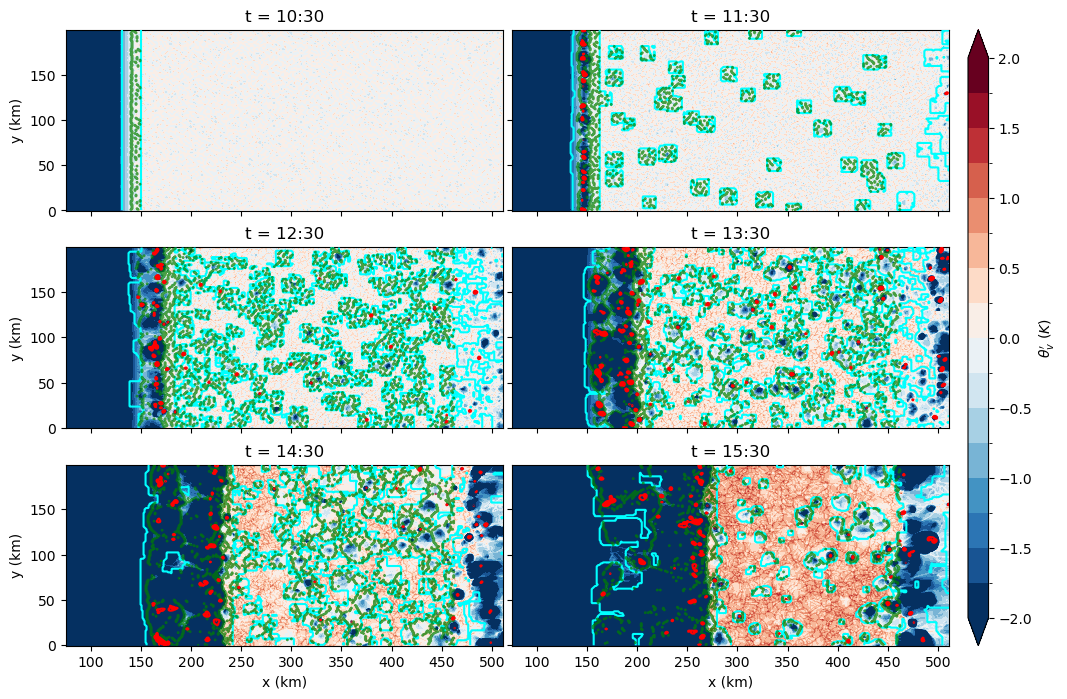

In [32]:
fig

In [ ]:
fig = MakeAllPlots_combined(variableName='conv',CLType="turbulentCL")
SaveFigure(fig,plotType=f"Project_Algorithms/Tracking_Algorithms/DiurnalCycleFigure",fileName=f"DiurnalCycleFigure_Convergence_turbulentCL")

In [35]:
fig = MakeAllPlots_combined(variableName='theta_v_prime',CLType="turbulentCL")
SaveFigure(fig,plotType=f"Project_Algorithms/Tracking_Algorithms/DiurnalCycleFigure",fileName=f"DiurnalCycleFigure_Theta_V_Prime_turbulentCL")

Loaded data from /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Code/OUTPUT/Project_Algorithms/Tracking_Algorithms/1km_5min_34nz/Eulerian_CLTracking/Eulerian_CLTracking_1km_5min_34nz_4-30-00.h5 (6 variables)

Loaded data from /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Code/OUTPUT/Project_Algorithms/Tracking_Algorithms/1km_5min_34nz/Eulerian_CLTracking/Eulerian_CLTracking_1km_5min_34nz_5-30-00.h5 (6 variables)

Loaded data from /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Code/OUTPUT/Project_Algorithms/Tracking_Algorithms/1km_5min_34nz/Eulerian_CLTracking/Eulerian_CLTracking_1km_5min_34nz_6-30-00.h5 (6 variables)

Loaded data from /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Code/OUTPUT/Project_Algorithms/Tracking_Algorithms/1km_5min_34nz/Eulerian_CLTracking/Eulerian_CLTracking_1km_5min_34nz_7-30-00.h5 (6 variables)

Loaded data from /mnt/lustre/koa/koastore/torri_group/air_direct

In [ ]:
####################################
#OLD CODE

In [ ]:
# def PlotAllFigures_V2(timeIndiceRanges):
    
#     fig = plt.figure(figsize=(12, 14))
#     gs = fig.add_gridspec(5, 2, wspace=0.13, hspace=0.25)
    
#     axes = gs.subplots()
    
#     columnOne = axes[:, 0]
#     columnTwo = axes[:, 1]
    
#     for count, (timeIndiceRange, ax1, ax2) in enumerate(
#         tqdm(zip(timeIndiceRanges, columnOne, columnTwo),
#              total=len(timeIndiceRanges))
#     ):
#         isLast = (count == len(timeIndiceRanges) - 1)
        
#         tIndex, tString = GetTimeInfo(timeIndiceRange)

#         # ---------------- LEFT COLUMN ----------------
#         theta_v = LoadVars(t=tIndex)
#         PlotThetaVContour(
#             ax1,
#             variable=theta_v,
#             minmax_variable=theta_v_minmax,
#             setXLabel=isLast
#         )
#         ax1.set_title(f"{tString} LT")

#         # ---------------- RIGHT COLUMN ----------------
#         PlotConvergenceAndCL(
#             ax2,
#             t=tIndex,
#             clim=(-8/1e3, 8/1e3),
#             setXLabel=isLast,
#             setYLabel=False)
#         ax2.set_title(f"{tString} LT")

#     return fig

# # def PlotAllFigures_V1(timeIndiceRanges):
    
# #     fig = plt.figure(figsize=(12, 14))
# #     gs = fig.add_gridspec(5, 2, wspace=0.13,hspace=0.25)
    
# #     axes = gs.subplots()
    
# #     columnOne = axes[:, 0]
# #     columnTwo = axes[:, 1]
    
# #     for count, (timeIndiceRange, axis) in enumerate(
# #         tqdm(zip(timeIndiceRanges, columnOne), total=len(timeIndiceRanges))):
# #         isLast = (count == len(timeIndiceRanges) - 1)
        
# #         [tIndex,tString] = GetTimeInfo(timeIndiceRange)
# #         theta_v = LoadVars(t=tIndex)
# #         PlotThetaVContour(axis, variable=theta_v, minmax_variable=theta_v_minmax,
# #                           setXLabel=isLast)
# #         axis.set_title(f"{tString} LT")    


# #     for count, (timeIndiceRange, axis) in enumerate(
# #         tqdm(zip(timeIndiceRanges, columnTwo), total=len(timeIndiceRanges))):
# #         isLast = (count == len(timeIndiceRanges) - 1)
        
# #         [tIndex,tString] = GetTimeInfo(timeIndiceRange)
# #         PlotConvergenceAndCL(axis, t=tIndex,
# #                              clim=(-8/1e3,8/1e3),
# #                              setXLabel=isLast,setYLabel=False)
# #         axis.set_title(f"{tString} LT")

# #     return fig

# timeIndiceRanges = ['_10-11', '_11-12', '_12-13', '_13-14','_14-17']
# fig = PlotAllFigures_V2(timeIndiceRanges)
# SaveFigure(fig,plotType=f"Project_Algorithms/Tracking_Algorithms/DiurnalCycleFigure",fileName=f"DiurnalCycleFigure")